In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

# Cinética de Procesos (Sesión 02)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 2. Ley de velocidad de reacción

## 2.4 Mediciones de la velocidad de reacción

### 2.4.1 ¿Cómo medir la velocidad de reacción?

La **velocidad de reacción** se puede expresar mediante una **ecuación algebraica empírica**, a la cuál se le conoce como **Ley de Velocidad**. 

Para muchas reacciones irrevesibles, la ley de velocidad se puede escribir como el producto de una constante de reacción, y una función de la concentración (actividades) de las especies químicas involucradas en la reacción.

Por ejemplo, para la reacción elemental homogénea irreversible prototipo:

$$
\mathrm{\underbrace{a\,A + b\,B}_{reactivos} \longrightarrow \underbrace{c\,C + d\,D}_{productos}}
$$

La ley de velocidad de reacción se expresa idealmente como el producto de la constante de reacción, y una función de la concentración de los reactivos:

$$-r_{A} = k(T) . f(C_{A}, C_{B})$$



<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$-r_{\mathrm{A}}$**: Velocidad de reacción (consumo) de la especie $\mathrm{A}$, en $[\mathrm{mol.m^{-3}.s^{-1}}]$.

- **$k(T)$**: constante de reacción, que es función de la temperatura, con unidades variables que incluyen al tiempo.

- **$f(C_{\mathrm{A}}, C_{\mathrm{B}})$**: función de la concentración de los reactivos, con unidades variables.

- **$C_{\mathrm{i}}$**: Concentración de la especie $\mathrm{i}$, en $[\mathrm{mol.m^{3}}]$.
</div>

</details>

<div class="alert alert-warning">

Al formular una ley de velocidad de reacción se obtiene una ecuación algebraica empírica, esto implica que la dependencia entre la velocidad de reacción, $-r_{\mathrm{A}}$, y la concentración de las especies, se debe determinar de forma experimental. O en caso que sea calculada por primeros principios, debe de verificarse de forma experimental.

</div>

<div class="alert alert-success">

**¿Cómo se puede medir la velocidad de reacción?**

Haciendo experimentos en un reactor tipo batch (reactor discontinuo o reactor por lotes).

</div>

Ecuación general de diseño de un reactor:


$$\underbrace{\frac{dN_j}{dt}}_{\mathrm{Acumulación}} = \underbrace{F_{j_0}}_{\mathrm{Entradas}} - \underbrace{F_{j}}_{\mathrm{Salidas}} + \underbrace{\int_{V} r_j dV}_{\mathrm{Generación/Consumo}}$$

<center>

| Reactor| Acrónimo | Ecuación de diseño (diferencial) | Esquema |
|---------|---------|--------------------|:-------:|
| Reactor discontinuo | BR      | $$\frac{dN_j}{dt} =  \int_{V} r_j dV$$ | <img src="figures/images/Fed_batch_reactor_FSTR.svg" style="width:75px" title="Batch Reactor"> |

</center>

Si se considera un reactor perfectamente agitado, en el que no hay variación espacial de las variables del sistema (e.g., temperatura, concentración de especies químicas, etc.), la tasa de reacción sera homogénea en todo el volumen del sistema. Entonces, el término $r_j$ se puede sacar de la integral, y la ecuación de diseño toma la forma:

$$\frac{dN_j}{dt} =  r_j V$$

Tomando en cuenta que $N_j = C_j V$, si se considera la hipótesis de volumen constante, la ecuación se puede simplificar a:

$$\frac{d C_j}{dt} = r_j$$

<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$\frac{dN_j}{dt}$**: Tasa  de acumulación de la especie $j$ en el sistema, $[\mathrm{mol.s^{-1}}]$.

- **$\frac{dC_j}{dt}$**: Tasa  de cambio de la concentración de la especie $j$ en el sistema, $[\mathrm{mol.s^{-1}}]$.

- **$r_{j}$**: Tasa de reacción de la especie $j$ por unidad de volumen, $[\mathrm{mol.m^{-3}.s^{-1}}]$.

- **$V$**: volumen del reactor, $[\mathrm{m^{3}}]$.

</div>

</details>

### 2.4.2 Método integral

El método integral consiste en comparar predicciones obtenidas a partir de la integración de ecuaciones de velocidad de reacción contra los datos experimentales de concentración vs tiempo.

Adaptado de: ***[Levenspiel, 1998, p. 60]***

Un reactivo $\mathrm{A}$ se decompone en un reactor batch

$$\mathrm{A \longrightarrow productos}$$

La composiicón de $\mathrm{A}$ en el reactor se mide a varios tiempos, y se reporta en forma tabulada.

In [2]:
t = np.array([0, 20, 40, 60, 120, 180, 300]) # [s]
cA = np.array([10, 8, 6, 5, 3, 2, 1]) # [mol/l]
df = pd.DataFrame({"t": t, 'cA': cA})
df

,t,cA
0,0,10
1,20,8
2,40,6
3,60,5
4,120,3
5,180,2
6,300,1


#### 2.4.2.1 Reacción orden cero

**Reacción de orden cero**

$$-r_{\mathrm{A}} = -\frac{d C_\mathrm{A}}{dt} = k$$

$$\int_{C_{\mathrm{A_{0}}}}^{\mathrm{C_{A}}} dC_{\mathrm{A}} = -k \int_{0}^{t} dt$$

$$C_{\mathrm{A}} = C_{\mathrm{A_{0}}} - kt$$

In [3]:
def rate_law_0(t, k, cA0):
    return cA0 - k*t

In [4]:
cA0 = cA[0]
eps = 1e-8
# ajuste de la ley de orden zero (mínimos cuadrados)
params, cov = curve_fit(
    f=rate_law_0, 
    xdata=t, 
    ydata=cA, 
    bounds=[(-np.inf, (cA0-eps)), (np.inf, (cA0+eps))]
)
k, cA0 = params[0], params[1]
print(f"k = {k:.2e} [mol/(l.s)]")
print(f"cA0 = {cA0:.2f} [mol/l]")

k = 3.85e-02 [mol/(l.s)]
cA0 = 10.00 [mol/l]


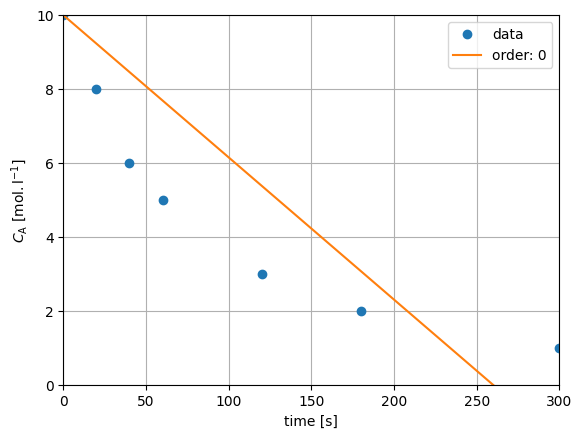

In [5]:
fig, ax = plt.subplots()
ax.plot(df['t'], df['cA'], ls='', marker='o', label='data')
ax.plot(t, rate_law_0(t, *params), label='order: 0')
ax.set(
    xlabel="time [s]",
    ylabel=r"$C_{\mathrm{A}}$ [$\mathrm{mol.l^{-1}}$]",
    xlim = (0, 300),
    ylim = (0, 10)
)
ax.grid()
ax.legend()
plt.show()

#### 2.4.2.1 Reacción orden uno

**Reacción de orden uno**

$$-r_{\mathrm{A}} = -\frac{d C_\mathrm{A}}{dt} = k C_{\mathrm{A}}$$

$$-\int_{C_{\mathrm{A_{0}}}}^{\mathrm{C_{A}}} \frac{dC_{\mathrm{A}}}{C_{\mathrm{A}}} = k \int_{0}^{t} dt$$

$$\ln \frac{C_{\mathrm{A_{0}}}}{C_{\mathrm{A}}} =  kt$$

In [6]:
def rate_law_1(t, k, cA0):
    return cA0 * np.exp(-k*t)

In [7]:
cA0 = cA[0]
eps = 1e-8
# ajuste de la ley de orden zero (mínimos cuadrados)
params, cov = curve_fit(
    f=rate_law_1, 
    xdata=t, 
    ydata=cA, 
    bounds=[(eps, (cA0-eps)), (np.inf, (cA0+eps))]
)
k, cA0 = params[0], params[1]
print(f"k = {k:.2e} [1/s]")
print(f"cA0 = {cA0:.2f} [mol/l]")

k = 1.05e-02 [1/s]
cA0 = 10.00 [mol/l]


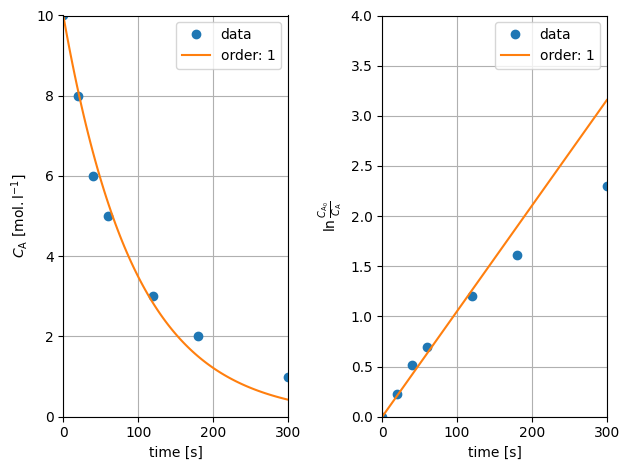

In [8]:
fig, (ax0, ax1) = plt.subplots(ncols = 2)

# "raw data" vs model
ax0.plot(df['t'], df['cA'], ls='', marker='o', label='data')
tt = np.linspace(0, 300, 100)
ax0.plot(tt, rate_law_1(tt, *params), label='order: 1')
ax0.set(
    xlabel="time [s]",
    ylabel=r"$C_{\mathrm{A}}$ [$\mathrm{mol.l^{-1}}$]",
    xlim = (0, 300),
    ylim = (0, 10)
)
ax0.grid()
ax0.legend()

# "treated data" vs model
ax1.plot(df['t'], np.log(cA0/df['cA']), ls='', marker='o', label='data')
ax1.plot(t, k*t, label='order: 1')
ax1.set(
    xlabel="time [s]",
    ylabel=r"$\ln \frac{C_{\mathrm{A_0}}}{C_{\mathrm{A}}}$",
    xlim = (0, 300),
    ylim = (0, 4)
)
ax1.grid()
ax1.legend()

fig.tight_layout()
plt.show()

#### 2.4.2.3 Reacción orden dos

**Reacción de orden dos**

$$-r_{\mathrm{A}} = -\frac{d C_\mathrm{A}}{dt} = k C_{\mathrm{A}}^2$$

$$-\int_{C_{\mathrm{A_{0}}}}^{\mathrm{C_{A}}} \frac{dC_{\mathrm{A}}}{C_{\mathrm{A}}^2} = k \int_{0}^{t} dt$$

$$\frac{1}{C_{\mathrm{A}}} - \frac{1}{C_{\mathrm{A_0}}} =  kt$$

In [9]:
def rate_law_2(t, k, cA0):
    return 1 / (k*t + 1/cA0)

In [10]:
cA0 = cA[0]
eps = 1e-8
# ajuste de la ley de orden zero (mínimos cuadrados)
params, cov = curve_fit(
    f=rate_law_2, 
    xdata=t, 
    ydata=cA, 
    bounds=[(eps, (cA0-eps)), (np.inf, (cA0+eps))]
)
k, cA0 = params[0], params[1]
print(f"k = {k:.2e} [l/(mol.s)]")
print(f"cA0 = {cA0:.2f} [mol/l]")

k = 1.77e-03 [l/(mol.s)]
cA0 = 10.00 [mol/l]


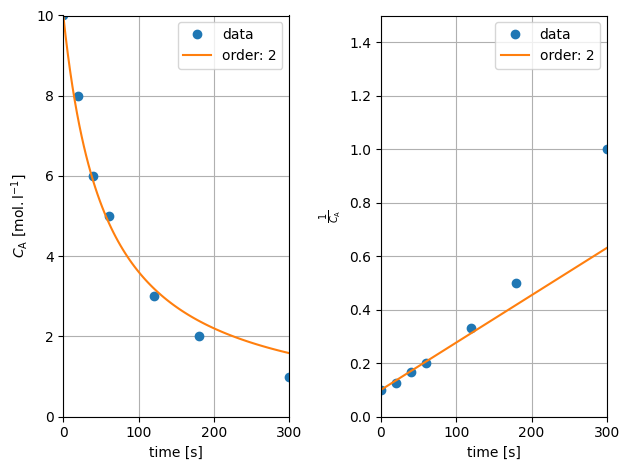

In [11]:
fig, (ax0, ax1) = plt.subplots(ncols = 2)

# "raw data" vs model
ax0.plot(df['t'], df['cA'], ls='', marker='o', label='data')
tt = np.linspace(0, 300, 100)
ax0.plot(tt, rate_law_2(tt, *params), label='order: 2')
ax0.set(
    xlabel="time [s]",
    ylabel=r"$C_{\mathrm{A}}$ [$\mathrm{mol.l^{-1}}$]",
    xlim = (0, 300),
    ylim = (0, 10)
)
ax0.grid()
ax0.legend()

# "treated data" vs model
ax1.plot(df['t'], 1/df['cA'], ls='', marker='o', label='data')
ax1.plot(t, k*t + 1/cA0, label='order: 2')
ax1.set(
    xlabel="time [s]",
    ylabel=r"$\frac{1}{C_{\mathrm{A}}}$",
    xlim = (0, 300),
    ylim = (0, 1.5)
)
ax1.grid()
ax1.legend()

fig.tight_layout()
plt.show()

#### 2.4.2.3 Reacción orden $n$

**Reacción de orden $n$**

$$-r_{\mathrm{A}} = -\frac{d C_\mathrm{A}}{dt} = k C_{\mathrm{A}}^{n}$$

$$-\int_{C_{\mathrm{A_{0}}}}^{\mathrm{C_{A}}} \frac{dC_{\mathrm{A}}}{C_{\mathrm{A}}^{n}} = k \int_{0}^{t} dt$$

$$C_{\mathrm{A}}^{(1-n)} - C_{\mathrm{A_0}}^{(1-n)} =  (n-1)kt$$

In [12]:
def rate_law_n(t, k, cA0, n):
    rhs = np.power(cA0, 1-n)  + (n-1)*k*t
    return np.power(rhs, 1/(1-n))

In [13]:
cA0 = cA[0]
eps = 1e-8
# ajuste de la ley de orden zero (mínimos cuadrados)
params, cov = curve_fit(
    f=rate_law_n, 
    xdata=t, 
    ydata=cA, 
    bounds=[(eps, (cA0-eps), 1+eps), (np.inf, (cA0+eps), np.inf)]
)
k, cA0, n = params[0], params[1], params[2]
print(f"k = {k:.2e} [###/s]")
print(f"cA0 = {cA0:.2f} [mol/l]")
print(f"n = {n:.2f}")

k = 4.71e-03 [###/s]
cA0 = 10.00 [mol/l]
n = 1.46


/tmp/ipykernel_13559/2924480356.py:3: RuntimeWarning: divide by zero encountered in power
  return np.power(rhs, 1/(1-n))


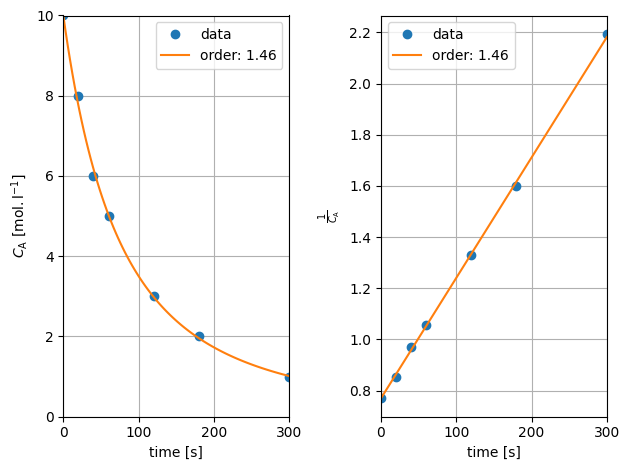

In [14]:
fig, (ax0, ax1) = plt.subplots(ncols = 2)

# "raw data" vs model
ax0.plot(df['t'], df['cA'], ls='', marker='o', label='data')
tt = np.linspace(0, 300, 100)
ax0.plot(tt, rate_law_n(tt, *params), label=f'order: {n:.2f}')
ax0.set(
    xlabel="time [s]",
    ylabel=r"$C_{\mathrm{A}}$ [$\mathrm{mol.l^{-1}}$]",
    xlim = (0, 300),
    ylim = (0, 10)
)
ax0.grid()
ax0.legend()

# "treated data" vs model
ax1.plot(df['t'], df['cA']**(1-n)/(n-1), ls='', marker='o', label='data')
ax1.plot(t, k*t + cA0**(1-n)/(n-1), label=f'order: {n:.2f}')
ax1.set(
    xlabel="time [s]",
    ylabel=r"$\frac{1}{C_{\mathrm{A}}}$",
    xlim = (0, 300),
    #ylim = (0, 1.5)
)
ax1.grid()
ax1.legend()

fig.tight_layout()
plt.show()

## 2.5 Aplicaciones de modelos de series de potencias

#### 2.3.1.3 Ejemplos de aplicación del modelo de series de potencias

##### 2.3.1.3.1 Ejemplo: Ley de reacción de orden cero

Adaptado de: [chem.libretexts.org](https://chem.libretexts.org/Bookshelves/General_Chemistry/Map%3A_General_Chemistry_(Petrucci_et_al.)/14%3A_Chemical_Kinetics/14.04%3A_Zero-Order_Reactions)

La reacción de descomposición de $\mathrm{N_2O}$ en $\mathrm{N_2}$ y $\mathrm{O_2}$, sobre una superficie de $\mathrm{Pt}$ (catalizador), exhibe una cinética de orden cero. La presencia del catalizador permite que la reacción ocurra en el rango $200$ a $400$ $\mathrm{^{\circ}C}$. La concentración de $\mathrm{N_2O}$ no tiene incidencia en la tasa de reacción siempre y cuando haya suficiente $\mathrm{N_2O}$ para cubrir toda la superficie del catalizador. Sin la presencia del catalizador, esta reacción requiere temperaturas superiores a $700$ $\mathrm{^{\circ}C}$ para llevarse a cabo.

$$ \mathrm{2 {N_2O}_{(g)} \xrightarrow[]{Pt} 2 {N_2}_{(g)} + {O_2}_{(g)}}$$

Con notación simplificada, la reacción se puede expresar como:

$$ \mathrm{2A \xrightarrow[]{X} 2B + C}$$

Y las velocidades relativas de reacción para el resto de las especies están dadas por:

$$\frac{r_{\mathrm{A}}}{-2} = \frac{r_{\mathrm{B}}}{2} = \frac{r_{\mathrm{C}}}{1}$$

**Construcción de un modelo cinético de orden cero**:

$$r_{\mathrm{A}} = k$$

$$\frac{dC_{\mathrm{A}}}{dt} = r_{\mathrm{A}}$$

$$\frac{dC_{\mathrm{B}}}{dt} = -r_{\mathrm{A}}$$

$$\frac{dC_{\mathrm{C}}}{dt} = -\frac{1}{2}r_{\mathrm{A}}$$

In [17]:
# Modelo cinético
def kinetic_model0(t, c, k):
    rA = -k # constante cinética
    dcA_dt = rA; dcB_dt = -rA; dcC_dt = -1/2*rA
    return np.array([dcA_dt, dcB_dt, dcC_dt])

# Terminar el cálculo si el reactivo A es consumido completamente
def Aconsumed(t, c, k): return c[0] 
Aconsumed.terminal = True

In [18]:
# parámetros de entrada para solución del sistema de ecuaciones diferenciales ordinarias
k = 0.1 # constante de reacción orden cero, en [u.a.^-1]
c0 = np.array([1, 0, 0]) # concentraciones iniciales de [A, B, C], en [u.a.]
t_span = (0, 20) # rango de tiempo para integración, en [u.a.]
dt = 0.1 # paso de tiempo, en [u.a.]
t_eval = np.arange(t_span[0], t_span[1]+dt, dt) # array con tiempos en los que se evalua la integración, en [u.a.]

# solución del sistema de ecuaciones diferenciales ordinarias, considerando evento para terminación del cálculo.
sol0 = solve_ivp(kinetic_model0, t_span, y0=c0, args=(k,), events=Aconsumed, t_eval=t_eval)

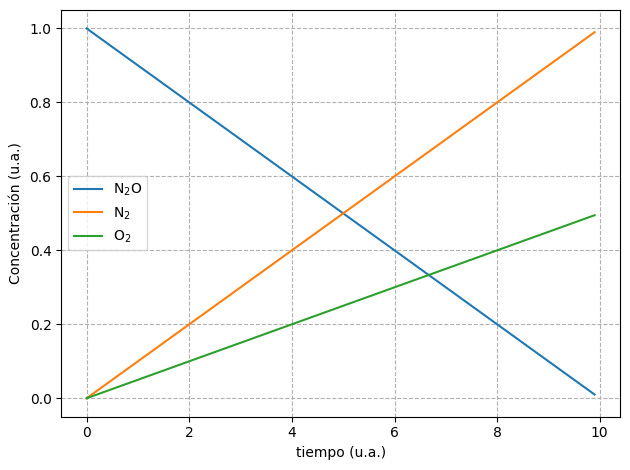

In [19]:
fig, ax = plt.subplots()
ax.plot(sol0.t, sol0.y[0], label=r'$\mathrm{N_2O}$')
ax.plot(sol0.t, sol0.y[1], label=r'$\mathrm{N_2}$')
ax.plot(sol0.t, sol0.y[2], label='$\mathrm{O_2}$')
ax.set(xlabel="tiempo (u.a.)", ylabel="Concentración (u.a.)")
ax.grid(ls="--")
ax.legend()
fig.tight_layout()
plt.show()

##### 2.3.1.3.2 Ejemplo: Ley de reacción de orden uno

Adaptado de: [chem.libretexts.org](https://chem.libretexts.org/Bookshelves/General_Chemistry/Map%3A_General_Chemistry_(Petrucci_et_al.)/14%3A_Chemical_Kinetics/14.05%3A_First-Order_Reactions)

A alta temperatura el cloetano produce ácido clorhídrico y etileno de acuerdo a la siguiente reacción:

$$ \mathrm{{CH_3CH_2Cl}_{(g)} \xrightarrow[]{\Delta} {HCl}_{(g)} + {C_2H_4}_{(g)}}$$

Con notación simplificada, la reacción se puede expresar como:

$$ \mathrm{A \xrightarrow[]{\Delta} B + C}$$

Y las velocidades relativas de reacción para el resto de las especies están dadas por:

$$\frac{r_{\mathrm{A}}}{-1} = \frac{r_{\mathrm{B}}}{1} = \frac{r_{\mathrm{C}}}{1}$$

**Construcción de un modelo cinético de orden uno**:

$$r_{\mathrm{A}} = k C_{\mathrm{A}}$$

$$\frac{dC_{\mathrm{A}}}{dt} = r_{\mathrm{A}}$$

$$\frac{dC_{\mathrm{B}}}{dt} = -r_{\mathrm{A}}$$

$$\frac{dC_{\mathrm{C}}}{dt} = -r_{\mathrm{A}}$$

In [20]:
# Modelo cinético
def kinetic_model1(t, c, k):
    cA, cB, cC = c
    rA = -k*cA # constante cinética
    dcA_dt = rA; dcB_dt = -rA; dcC_dt = -rA
    return np.array([dcA_dt, dcB_dt, dcC_dt])

# Terminar el cálculo si el reactivo A es consumido completamente
def Aconsumed(t, c, k): return c[0] 
Aconsumed.terminal = True

In [21]:
# parámetros de entrada para solución del sistema de ecuaciones diferenciales ordinarias
k = 1e-1 # constante de reacción orden cero, en [u.a.^-1]
c0 = np.array([1, 0.1, 0]) # concentraciones iniciales de [A, B, C], en [u.a.]
t_span = (0, 100) # rango de tiempo para integración, en [u.a.]
dt = 1 # paso de tiempo, en [u.a.]
t_eval = np.arange(t_span[0], t_span[1]+dt, dt) # array con tiempos en los que se evalua la integración, en [u.a.]

# solución del sistema de ecuaciones diferenciales ordinarias, considerando evento para terminación del cálculo.
sol1 = solve_ivp(kinetic_model1, t_span, y0=c0, args=(k,), events=Aconsumed, t_eval=t_eval)

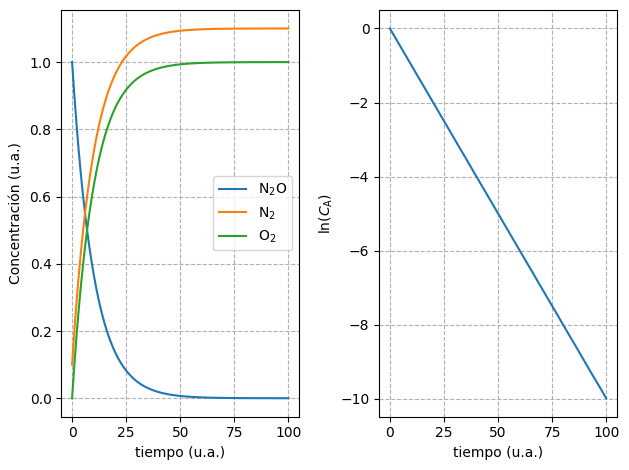

In [22]:
fig, axes = plt.subplots(ncols=2)
ax=axes[0]
ax.plot(sol1.t, sol1.y[0], label=r'$\mathrm{N_2O}$')
ax.plot(sol1.t, sol1.y[1], label=r'$\mathrm{N_2}$')
ax.plot(sol1.t, sol1.y[2], label='$\mathrm{O_2}$')
ax.set(xlabel="tiempo (u.a.)", ylabel="Concentración (u.a.)")
ax.grid(ls="--")
ax.legend()
ax=axes[1]
ax.plot(sol1.t, np.log(sol1.y[0]))
ax.set(xlabel='tiempo (u.a.)', ylabel=r"$\ln (C_{\mathrm{A}})$")
ax.grid(ls="--")
fig.tight_layout()
plt.show()

##### 2.3.1.3.3 Ejemplo: Ley de reacción de orden dos

Adaptado de: [chem.libretexts.org](https://chem.libretexts.org/Bookshelves/General_Chemistry/Map%3A_General_Chemistry_(Petrucci_et_al.)/14%3A_Chemical_Kinetics/14.06%3A_Second-Order_Reactions)

A alta temperatura el dióxido de nitrógeno se descompone en óxido nitrico y oxígeno de acuerdo con la reacción:

$$ \mathrm{2{NO_2}_{(g)} \xrightarrow[]{\Delta} 2{NO}_{(g)} + {O_2}_{(g)}}$$

Con notación simplificada, la reacción se puede expresar como:

$$ \mathrm{2A \xrightarrow[]{\Delta} 2B + C}$$

Y las velocidades relativas de reacción para el resto de las especies están dadas por:

$$\frac{r_{\mathrm{A}}}{-2} = \frac{r_{\mathrm{B}}}{2} = \frac{r_{\mathrm{C}}}{1}$$

**Construcción de un modelo cinético de orden dos**:

$$r_{\mathrm{A}} = k C_{\mathrm{A}}^2$$

$$\frac{dC_{\mathrm{A}}}{dt} = r_{\mathrm{A}}$$

$$\frac{dC_{\mathrm{B}}}{dt} = -r_{\mathrm{A}}$$

$$\frac{dC_{\mathrm{C}}}{dt} = -\frac{1}{2} r_{\mathrm{A}}$$

In [23]:
# Modelo cinético
def kinetic_model2(t, c, k):
    cA, cB, cC = c
    rA = -k*(cA)**2 # constante cinética
    dcA_dt = rA; dcB_dt = -rA; dcC_dt = -rA
    return np.array([dcA_dt, dcB_dt, dcC_dt])

# Terminar el cálculo si el reactivo A es consumido completamente
def Aconsumed(t, c, k): return c[0] 
Aconsumed.terminal = True

In [24]:
# parámetros de entrada para solución del sistema de ecuaciones diferenciales ordinarias
k = 1e-1 # constante de reacción orden cero, en [u.a.^-1]
c0 = np.array([1, 0.1, 0]) # concentraciones iniciales de [A, B, C], en [u.a.]
t_span = (0, 100) # rango de tiempo para integración, en [u.a.]
dt = 1 # paso de tiempo, en [u.a.]
t_eval = np.arange(t_span[0], t_span[1]+dt, dt) # array con tiempos en los que se evalua la integración, en [u.a.]

# solución del sistema de ecuaciones diferenciales ordinarias, considerando evento para terminación del cálculo.
sol2 = solve_ivp(kinetic_model2, t_span, y0=c0, args=(k,), events=Aconsumed, t_eval=t_eval)

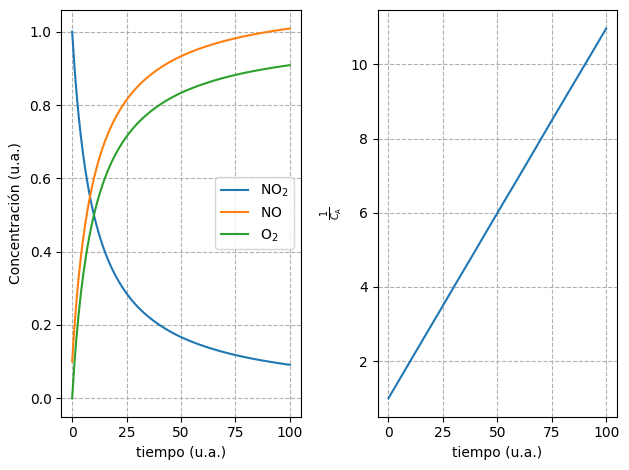

In [25]:
fig, axes = plt.subplots(ncols=2)
ax=axes[0]
ax.plot(sol2.t, sol2.y[0], label=r'$\mathrm{NO_2}$')
ax.plot(sol2.t, sol2.y[1], label=r'$\mathrm{NO}$')
ax.plot(sol2.t, sol2.y[2], label='$\mathrm{O_2}$')
ax.set(xlabel="tiempo (u.a.)", ylabel="Concentración (u.a.)")
ax.grid(ls="--")
ax.legend()
ax=axes[1]
ax.plot(sol2.t, 1/(sol2.y[0]))
ax.set(xlabel='tiempo (u.a.)', ylabel=r"$\frac{1}{C_{\mathrm{A}}}$")
ax.grid(ls="--")
fig.tight_layout()
plt.show()